# Projeto em Ciência de Dados — Grupo 4
## Notebook 2.0 — Modelação e Treino
**Afonso Carvalho & Marcello Portugal** | ISCAC

In [1]:
# Afonso Carvalho e Marcello Portugal
# Importacoes

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

## 1. Carregamento dos Dados

In [2]:
# Afonso Carvalho e Marcello Portugal
# Carregar o dataset final da M2 (com capping e feature engineering aplicados)

kaggle_path = '/kaggle/input/datasets/marcelloportugal/dataset-final-para-modelacao/wine_quality_model_final (1).csv'
local_path  = '../data/processed/wine_quality_model_final(1).csv'

data_path = kaggle_path if os.path.exists(kaggle_path) else local_path
df = pd.read_csv(data_path)

print(f'Dataset carregado: {df.shape[0]} registos x {df.shape[1]} colunas')
print(df.columns.tolist())

Dataset carregado: 6497 registos x 13 colunas
['fixed acidity', 'citric acid', 'residual sugar', 'chlorides', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'is_red', 'so2_ratio', 'volatile_acidity_ratio']


In [3]:
# Afonso Carvalho e Marcello Portugal
# Inspecao rapida e verificacao de valores nulos

print('Nulos por coluna:')
print(df.isnull().sum())
df.head(5)

Nulos por coluna:
fixed acidity             0
citric acid               0
residual sugar            0
chlorides                 0
total sulfur dioxide      0
density                   0
pH                        0
sulphates                 0
alcohol                   0
quality                   0
is_red                    0
so2_ratio                 0
volatile_acidity_ratio    0
dtype: int64


,fixed acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red,so2_ratio,volatile_acidity_ratio
0,7.40,0.04,1.9,0.076,34.0,0.9978,3.51,0.56,9.4,5,1,0.323529,0.088514
1,7.80,0.04,2.6,0.098,67.0,0.9968,3.20,0.68,9.8,5,1,0.373134,0.083974
2,7.80,0.04,2.3,0.092,54.0,0.9970,3.26,0.65,9.8,5,1,0.277778,0.083974
3,9.65,0.56,1.9,0.075,60.0,0.9980,3.16,0.58,9.8,6,1,0.283333,0.029016
4,7.40,0.04,1.9,0.076,34.0,0.9978,3.51,0.56,9.4,5,1,0.323529,0.088514


## 2. Separacao de Features e Variavel Alvo

In [4]:
# Afonso Carvalho e Marcello Portugal
# X = variaveis preditoras | y = qualidade (variavel alvo)

TARGET = 'quality'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Features: {X.shape[1]} variaveis')
print(f'Alvo: "{TARGET}" | Distribuicao: {dict(y.value_counts().sort_index())}')

Features: 12 variaveis
Alvo: "quality" | Distribuicao: {3: np.int64(30), 4: np.int64(216), 5: np.int64(2138), 6: np.int64(2836), 7: np.int64(1079), 8: np.int64(193), 9: np.int64(5)}


## 3. Divisao Treino / Teste (Aula 15)
Divisao 80/20 com semente fixa para garantir reprodutibilidade.

In [5]:
# Afonso Carvalho e Marcello Portugal
# Divisao Hold-Out 80/20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'Treino : {X_train.shape[0]} registos ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Teste  : {X_test.shape[0]}  registos ({X_test.shape[0]/len(df)*100:.1f}%)')

Treino : 5197 registos (80.0%)
Teste  : 1300  registos (20.0%)


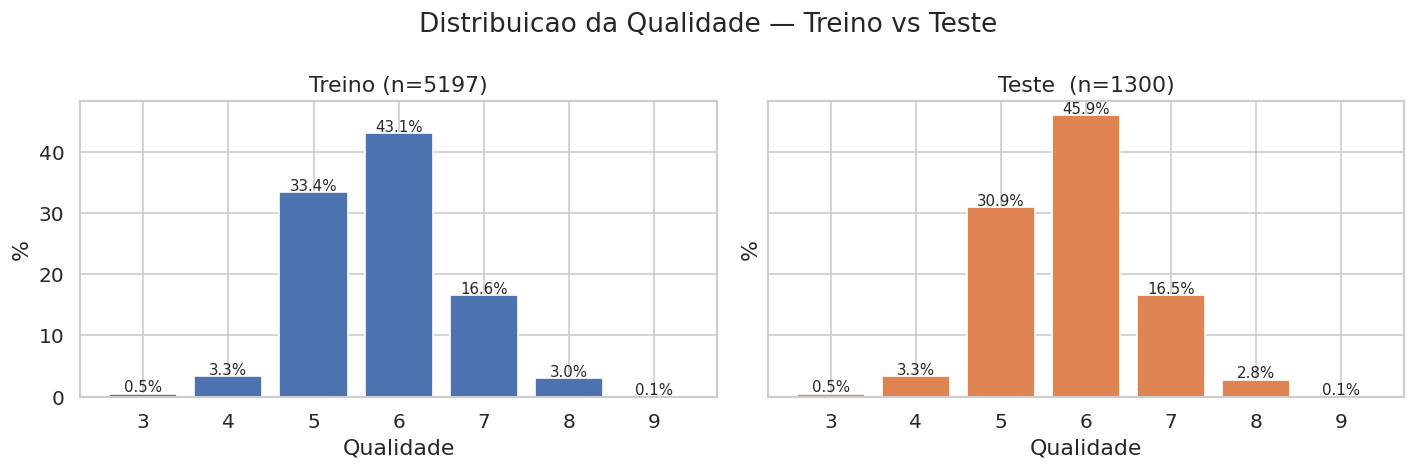

In [6]:
# Afonso Carvalho e Marcello Portugal
# Verificar se a distribuicao de 'quality' e semelhante em treino e teste

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (data, title, color) in zip(
    axes,
    [(y_train, f'Treino (n={len(y_train)})', '#4C72B0'),
     (y_test,  f'Teste  (n={len(y_test)})',  '#DD8452')]
):
    counts = data.value_counts().sort_index()
    pct    = counts / len(data) * 100
    ax.bar(counts.index, pct, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Qualidade')
    ax.set_ylabel('%')
    for v, p in zip(counts.index, pct):
        ax.text(v, p + 0.3, f'{p:.1f}%', ha='center', fontsize=9)

plt.suptitle('Distribuicao da Qualidade — Treino vs Teste')
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/M3_split_distribuicao.png', bbox_inches='tight')
plt.show()

## 4. Normalizacao dos Dados
O StandardScaler e ajustado apenas no treino para evitar fuga de informacao (*data leakage*).

In [7]:
# Afonso Carvalho e Marcello Portugal
# StandardScaler: fit apenas no treino, transform em ambos

scaler = StandardScaler()

X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print('Normalizacao aplicada.')
print(f'Media de alcohol no treino: {scaler.mean_[X_train.columns.get_loc("alcohol")]:.4f}')

Normalizacao aplicada.
Media de alcohol no treino: 10.4836


## 5. Metricas de Avaliacao (Aula 15)
Problema de regressao — metricas escolhidas: MAE (principal), RMSE e R².

In [8]:
# Afonso Carvalho e Marcello Portugal
# Funcao de avaliacao: calcula MAE, RMSE e R2 para treino e teste

def avaliar_modelo(nome, y_treino, y_treino_pred, y_teste, y_teste_pred):
    return {
        'Modelo'       : nome,
        'MAE Treino'   : round(mean_absolute_error(y_treino, y_treino_pred), 4),
        'RMSE Treino'  : round(np.sqrt(mean_squared_error(y_treino, y_treino_pred)), 4),
        'R2 Treino'    : round(r2_score(y_treino, y_treino_pred), 4),
        'MAE Teste'    : round(mean_absolute_error(y_teste, y_teste_pred), 4),
        'RMSE Teste'   : round(np.sqrt(mean_squared_error(y_teste, y_teste_pred)), 4),
        'R2 Teste'     : round(r2_score(y_teste, y_teste_pred), 4),
    }

todos_resultados = []
print('Funcao de avaliacao definida. Objetivo: MAE < 0.5 no teste.')

Funcao de avaliacao definida. Objetivo: MAE < 0.5 no teste.


## 6. Modelos Baseline (Aula 16)

In [9]:
# Afonso Carvalho e Marcello Portugal
# B1: DummyRegressor — preve sempre a media do treino (pior caso razoavel)

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_sc, y_train)

res_dummy = avaliar_modelo(
    'B1 - Previsao pela Media',
    y_train, dummy.predict(X_train_sc),
    y_test,  dummy.predict(X_test_sc)
)
todos_resultados.append(res_dummy)

print('B1 — Previsao pela Media')
for k, v in res_dummy.items():
    print(f'  {k}: {v}')

B1 — Previsao pela Media
  Modelo: B1 - Previsao pela Media
  MAE Treino: 0.691
  RMSE Treino: 0.8766
  R2 Treino: 0.0
  MAE Teste: 0.6691
  RMSE Teste: 0.8596
  R2 Teste: -0.0005


In [10]:
# Afonso Carvalho e Marcello Portugal
# B2: Regressao Linear — modelo mais simples que usa de facto as variaveis

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

res_lr = avaliar_modelo(
    'B2 - Regressao Linear',
    y_train, lr.predict(X_train_sc),
    y_test,  lr.predict(X_test_sc)
)
todos_resultados.append(res_lr)

print('B2 — Regressao Linear')
for k, v in res_lr.items():
    print(f'  {k}: {v}')

B2 — Regressao Linear
  Modelo: B2 - Regressao Linear
  MAE Treino: 0.5659
  RMSE Treino: 0.7314
  R2 Treino: 0.3038
  MAE Teste: 0.5607
  RMSE Teste: 0.7285
  R2 Teste: 0.2814


In [11]:
# Afonso Carvalho e Marcello Portugal
# Coeficientes da regressao linear (ordenados por impacto absoluto)

coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print('Coeficientes:')
print(coefs.round(4).to_string())

Coeficientes:
alcohol                   0.3023
residual sugar            0.2476
volatile_acidity_ratio   -0.2328
density                  -0.2323
sulphates                 0.1202
is_red                    0.1165
so2_ratio                 0.0936
pH                        0.0526
chlorides                -0.0317
fixed acidity            -0.0164
citric acid               0.0058
total sulfur dioxide     -0.0014


In [12]:
# Afonso Carvalho e Marcello Portugal
# Tabela comparativa dos dois baselines

df_resultados = pd.DataFrame(todos_resultados).set_index('Modelo')
display(df_resultados.style
    .format('{:.4f}')
    .highlight_min(subset=['MAE Teste', 'RMSE Teste'], color='#d4edda')
    .highlight_max(subset=['R2 Teste'], color='#d4edda')
)

,MAE Treino,RMSE Treino,R2 Treino,MAE Teste,RMSE Teste,R2 Teste
Modelo,,,,,,
B1 - Previsao pela Media,0.6910,0.8766,0.0000,0.6691,0.8596,-0.0005
B2 - Regressao Linear,0.5659,0.7314,0.3038,0.5607,0.7285,0.2814


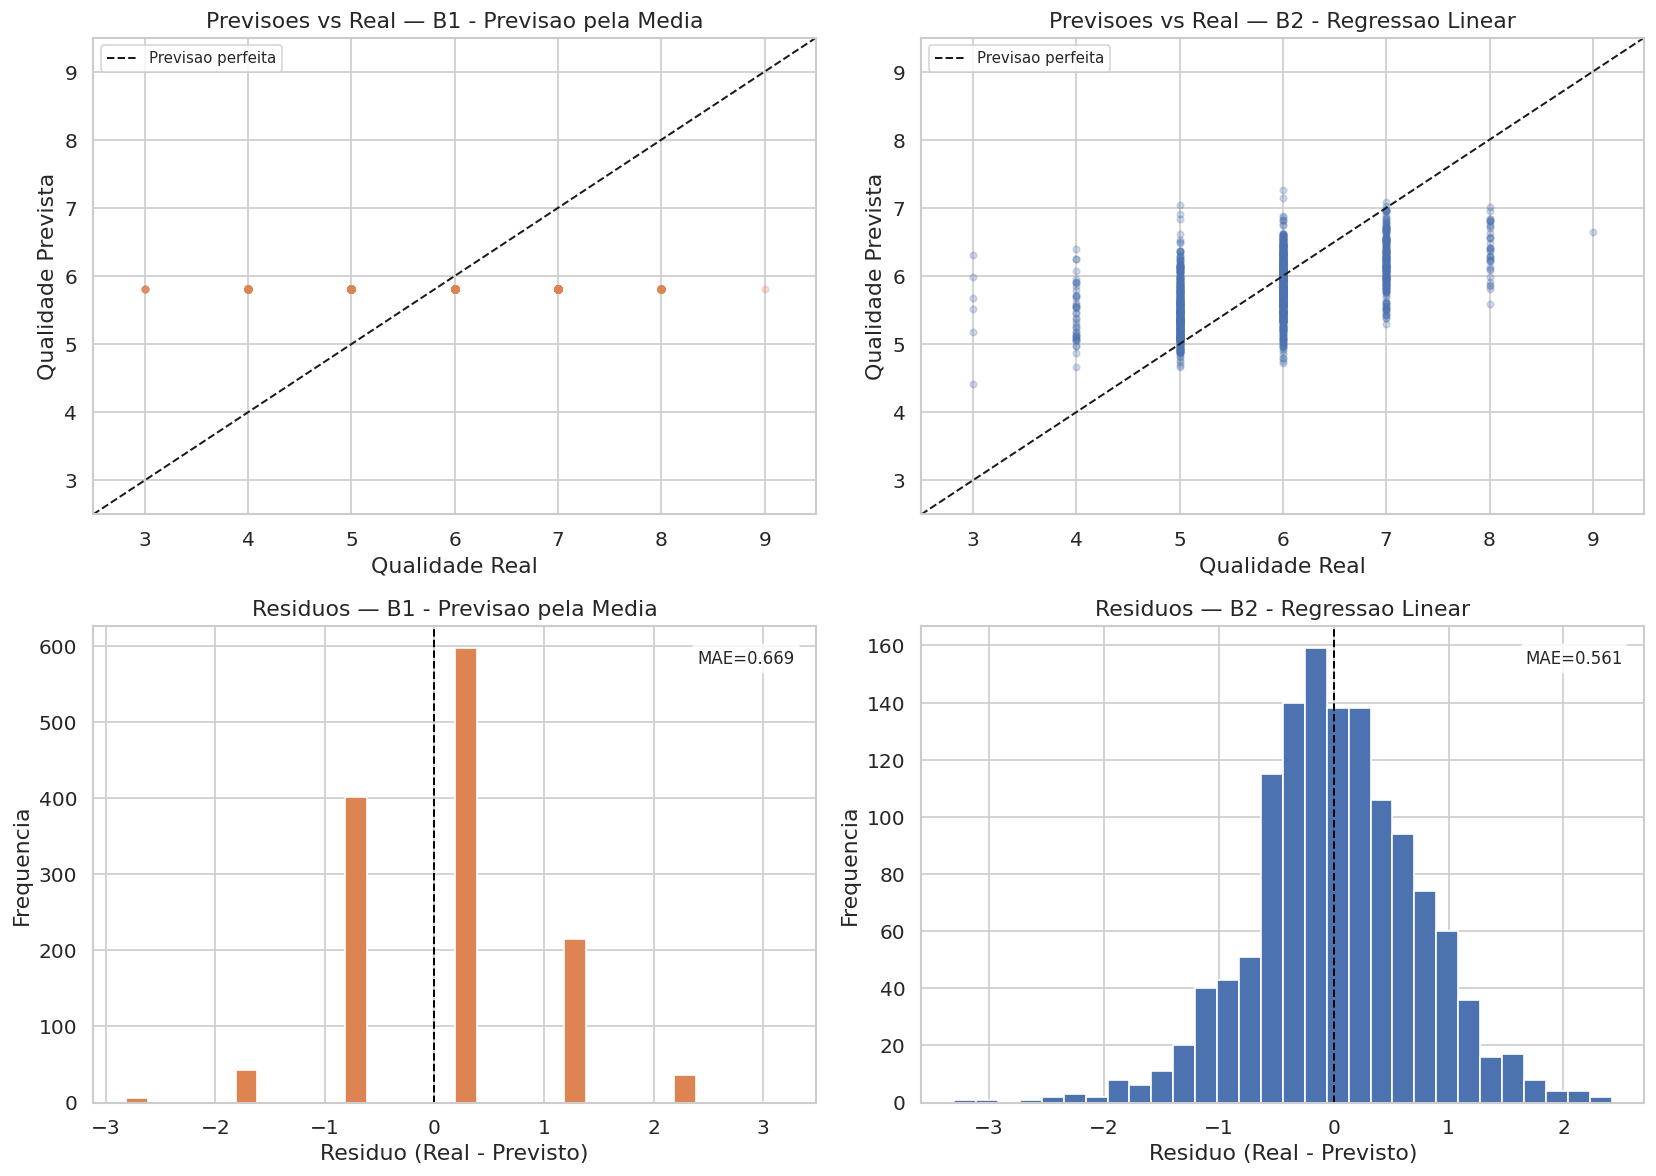

In [13]:
# Afonso Carvalho e Marcello Portugal
# Graficos: previsoes vs valores reais e distribuicao dos residuos

y_dummy_te = dummy.predict(X_test_sc)
y_lr_te    = lr.predict(X_test_sc)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (y_pred, titulo, cor) in enumerate([
    (y_dummy_te, 'B1 - Previsao pela Media', '#DD8452'),
    (y_lr_te,    'B2 - Regressao Linear',    '#4C72B0')
]):
    # previsoes vs real
    ax = axes[0, i]
    ax.scatter(y_test, y_pred, alpha=0.25, s=15, color=cor)
    lims = [y_test.min() - 0.5, y_test.max() + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Previsao perfeita')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Qualidade Real'); ax.set_ylabel('Qualidade Prevista')
    ax.set_title(f'Previsoes vs Real — {titulo}')
    ax.legend(fontsize=9)

    # residuos
    ax = axes[1, i]
    residuos = y_test - y_pred
    ax.hist(residuos, bins=30, color=cor, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Residuo (Real - Previsto)'); ax.set_ylabel('Frequencia')
    ax.set_title(f'Residuos — {titulo}')
    ax.text(0.97, 0.95, f'MAE={mean_absolute_error(y_test, y_pred):.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../reports/figures/M3_baseline_graficos.png', bbox_inches='tight')
plt.show()

In [14]:
# Afonso Carvalho e Marcello Portugal
# Guardar resultados e verificar distancia face ao objetivo

os.makedirs('../reports', exist_ok=True)
df_resultados.to_csv('../reports/M3_resultados_baseline.csv')

mae_lr_teste = res_lr['MAE Teste']
print(f'Objetivo: MAE < 0.5 no conjunto de teste')
print(f'Melhor baseline (B2 - Regressao Linear): MAE = {mae_lr_teste}')
gap = mae_lr_teste - 0.5
if gap > 0:
    print(f'Diferenca para o objetivo: {gap:.4f} pontos — necessario usar modelos mais avancados.')
else:
    print(f'Objetivo alcancado no baseline. Margem: {abs(gap):.4f}')

Objetivo: MAE < 0.5 no conjunto de teste
Melhor baseline (B2 - Regressao Linear): MAE = 0.5607
Diferenca para o objetivo: 0.0607 pontos — necessario usar modelos mais avancados.
